---
# CALINET NeuroKit2

In [1]:
%reload_ext autoreload
%autoreload 2

In [29]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

from lazyfmri import plotting

import calinet.core.io as cio
from calinet.config import stim_colors

import neurokit2 as nk


In [3]:
%matplotlib inline
subj_path = Path(r'D:\teaching\2026\EMHFC_PsPM\PsPM_course_EMHFC2026\BIDS_Example\sub-Synth01')
phys_file = list(subj_path.glob("**/*physio.tsv.gz"))[0]
df_physio = cio.read_physio_tsv_headerless(phys_file)
df_physio.head()

,timestamp,scr
0,0.00,0.043100
1,0.01,0.008969
2,0.02,0.020400
3,0.03,0.043442
4,0.04,-0.006226


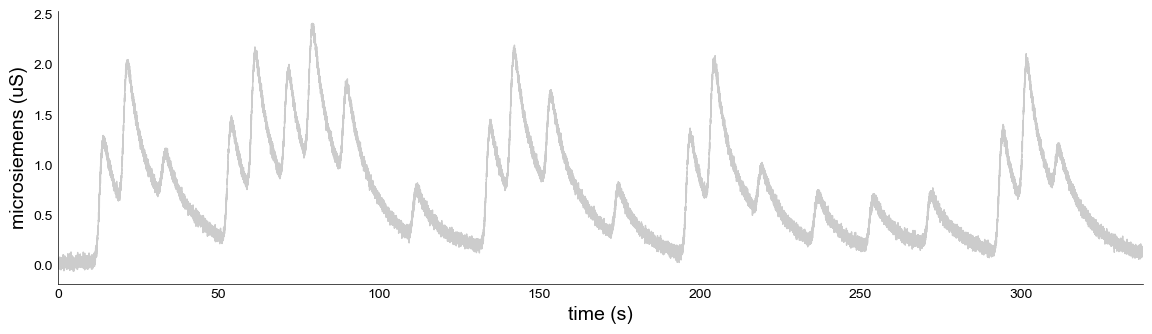

In [4]:
pl = plotting.LazyLine(
    df_physio['scr'].to_numpy(),
    xx=df_physio['timestamp'].to_numpy(),
    color='#cccccc',
    linewidth=0.5,
    figsize=(14, 3.54),
    fontname="Arial",
    x_label="time (s)",
    y_label="microsiemens (uS)"
)


In [5]:
df_physio.head()

,timestamp,scr
0,0.00,0.043100
1,0.01,0.008969
2,0.02,0.020400
3,0.03,0.043442
4,0.04,-0.006226


In [6]:
event_file = list(subj_path.glob("**/*events.tsv"))[0]
df_event = pd.read_csv(event_file, delimiter='\t')
df_event = df_event[~df_event['event_type'].str.contains("USp")]
print(df_event['event_type'].unique())
df_event.head()

['CSpr' 'CSm' 'CSpu']


,onset,duration,event_type,stimulus_name,task_name
0,10.000,8.0,CSpr,diamond,acquisition
2,29.504,8.0,CSm,square,acquisition
3,49.856,8.0,CSpr,diamond,acquisition
5,67.698,8.0,CSpr,diamond,acquisition
7,85.887,8.0,CSpu,diamond,acquisition


## Neurokit preparation

In [7]:
# sampling rate from timestamp
sampling_rate = round(1 / df_physio["timestamp"].diff().median())
eda = df_physio["scr"].to_numpy()

# events in samples
events = df_event.copy()
events["onset_sample"] = (events["onset"] * sampling_rate).round().astype(int)

event_samples = events["onset_sample"].to_list()
event_labels = (
    events["event_type"] + "_" +
    events["stimulus_name"] + "_" +
    events.index.astype(str)
).to_list()
event_labels

['CSpr_diamond_0',
 'CSm_square_2',
 'CSpr_diamond_3',
 'CSpr_diamond_5',
 'CSpu_diamond_7',
 'CSm_square_8',
 'CSpr_diamond_9',
 'CSpu_diamond_11',
 'CSm_square_12',
 'CSpr_diamond_13',
 'CSm_square_15',
 'CSm_square_16',
 'CSm_square_17',
 'CSm_square_18',
 'CSpr_diamond_19',
 'CSm_square_21']

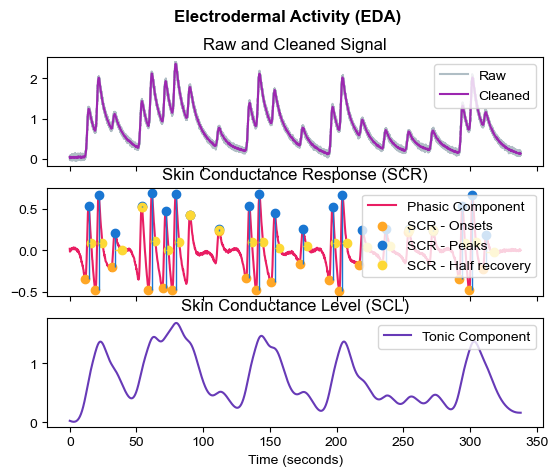

In [8]:
signals, info = nk.eda_process(
    eda,
    sampling_rate=sampling_rate,
    method="neurokit"
)

fig = nk.eda_plot(signals, info)

In [10]:
epochs = nk.epochs_create(
    signals,
    events=event_samples,
    sampling_rate=sampling_rate,
    epochs_start=-1,
    epochs_end=8,
    event_labels=event_labels
)

event_results = nk.eda_eventrelated(epochs)

In [11]:
events_valid = events.copy()
events_valid["Label"] = event_labels

event_results = nk.eda_eventrelated(epochs)

event_results = event_results.merge(
    events_valid,
    on="Label",
    how="left"
)

event_results.head()

,Label,Event_Onset,EDA_Peak_Amplitude,EDA_SCR,SCR_Peak_Amplitude,SCR_Peak_Amplitude_Time,SCR_RiseTime,SCR_RecoveryTime,onset,duration,event_type,stimulus_name,task_name,onset_sample
0,CSpr_diamond_0,1000,0.536377,1,0.882684,4.085651,2.46,1.88,10.000,8.0,CSpr,diamond,acquisition,1000
1,CSm_square_2,2950,0.214575,1,0.415565,4.265851,2.13,NaN,29.504,8.0,CSm,square,acquisition,2950
2,CSpr_diamond_3,4986,0.536806,1,0.018335,4.255840,0.21,0.08,49.856,8.0,CSpr,diamond,acquisition,4986
3,CSpr_diamond_5,6770,0.478256,1,0.934893,4.195773,2.34,2.02,67.698,8.0,CSpr,diamond,acquisition,6770
4,CSpu_diamond_7,8589,0.431476,1,0.006166,4.345940,0.17,0.06,85.887,8.0,CSpu,diamond,acquisition,8589


In [12]:
summary = (
    event_results
    .groupby(["event_type", "stimulus_name"])
    .agg(
        n=("EDA_SCR", "count"),
        response_rate=("EDA_SCR", "mean"),
        mean_peak_amp=("SCR_Peak_Amplitude", "mean"),
        median_peak_amp=("SCR_Peak_Amplitude", "median"),
        mean_latency=("SCR_Peak_Amplitude_Time", "mean"),
        mean_rise_time=("SCR_RiseTime", "mean"),
        mean_recovery_time=("SCR_RecoveryTime", "mean"),
    )
    .reset_index()
)

summary

,event_type,stimulus_name,n,response_rate,mean_peak_amp,median_peak_amp,mean_latency,mean_rise_time,mean_recovery_time
0,CSm,square,8,1.0,0.270900,0.413406,4.160734,1.446250,1.720000
1,CSpr,diamond,6,1.0,0.744193,0.880470,4.162403,1.993333,1.596667
2,CSpu,diamond,2,1.0,0.423130,0.423130,4.295884,1.310000,1.770000


In [13]:
methods = [
    "smoothmedian",
    "highpass",
    "cvxeda",
    "sparseda"
]

decomp_results = {}

for method in methods:
    phasic = nk.eda_phasic(
        signals["EDA_Clean"],
        sampling_rate=sampling_rate,
        method=method
    )

    tmp = signals.copy()
    tmp["EDA_Tonic"] = phasic["EDA_Tonic"]
    tmp["EDA_Phasic"] = phasic["EDA_Phasic"]

    epochs = nk.epochs_create(
        tmp,
        events=event_samples,
        sampling_rate=sampling_rate,
        epochs_start=-1,
        epochs_end=8,
        event_labels=event_labels
    )

    event_results = nk.eda_eventrelated(epochs)
    event_results = event_results.merge(
        events_valid,
        on="Label",
        how="left"
    )
    
    decomp_results[method] = event_results

comparison = pd.concat(decomp_results, names=["method"]).reset_index(level=0)
comparison.head()

,method,Label,Event_Onset,EDA_Peak_Amplitude,EDA_SCR,SCR_Peak_Amplitude,SCR_Peak_Amplitude_Time,SCR_RiseTime,SCR_RecoveryTime,onset,duration,event_type,stimulus_name,task_name,onset_sample
0,smoothmedian,CSpr_diamond_0,1000,0.171627,1,0.882684,4.085651,2.46,1.88,10.000,8.0,CSpr,diamond,acquisition,1000
1,smoothmedian,CSm_square_2,2950,0.098792,1,0.415565,4.265851,2.13,NaN,29.504,8.0,CSm,square,acquisition,2950
2,smoothmedian,CSpr_diamond_3,4986,0.199193,1,0.018335,4.255840,0.21,0.08,49.856,8.0,CSpr,diamond,acquisition,4986
3,smoothmedian,CSpr_diamond_5,6770,0.222404,1,0.934893,4.195773,2.34,2.02,67.698,8.0,CSpr,diamond,acquisition,6770
4,smoothmedian,CSpu_diamond_7,8589,0.176912,1,0.006166,4.345940,0.17,0.06,85.887,8.0,CSpu,diamond,acquisition,8589


In [14]:
import numpy as np
from scipy import stats

def ci_low(x, alpha=0.95):
    x = x.dropna()
    if len(x) < 2:
        return np.nan
    return stats.t.interval(
        alpha,
        len(x) - 1,
        loc=np.mean(x),
        scale=stats.sem(x)
    )[0]

def ci_high(x, alpha=0.95):
    x = x.dropna()
    if len(x) < 2:
        return np.nan
    return stats.t.interval(
        alpha,
        len(x) - 1,
        loc=np.mean(x),
        scale=stats.sem(x)
    )[1]

summary = (
    comparison
    .groupby(["method", "event_type"])
    .agg(
        n=("EDA_SCR", "count"),

        response_rate=("EDA_SCR", "mean"),

        mean_peak_amp=("EDA_Peak_Amplitude", "mean"),
        median_peak_amp=("EDA_Peak_Amplitude", "median"),

        ci_low=("EDA_Peak_Amplitude", ci_low),
        ci_high=("EDA_Peak_Amplitude", ci_high),

        mean_latency=("SCR_Peak_Amplitude_Time", "mean"),
        mean_rise_time=("SCR_RiseTime", "mean"),
        mean_recovery_time=("SCR_RecoveryTime", "mean"),
    )
    .reset_index()
)

summary

,method,event_type,n,response_rate,mean_peak_amp,median_peak_amp,ci_low,ci_high,mean_latency,mean_rise_time,mean_recovery_time
0,cvxeda,CSm,8,1.0,0.442856,0.432723,0.414351,0.471360,4.160734,1.446250,1.720000
1,cvxeda,CSpr,6,1.0,1.032332,1.030832,1.022544,1.042119,4.162403,1.993333,1.596667
2,cvxeda,CSpu,2,1.0,0.880633,0.880633,0.719101,1.042165,4.295884,1.310000,1.770000
3,highpass,CSm,8,1.0,0.241464,0.252993,0.217635,0.265294,4.160734,1.446250,1.720000
4,highpass,CSpr,6,1.0,0.525189,0.536059,0.500649,0.549730,4.162403,1.993333,1.596667
5,highpass,CSpu,2,1.0,0.442571,0.442571,0.301598,0.583543,4.295884,1.310000,1.770000
6,smoothmedian,CSm,8,1.0,0.096970,0.098387,0.087532,0.106408,4.160734,1.446250,1.720000
7,smoothmedian,CSpr,6,1.0,0.195269,0.193328,0.178139,0.212399,4.162403,1.993333,1.596667
8,smoothmedian,CSpu,2,1.0,0.187224,0.187224,0.056188,0.318261,4.295884,1.310000,1.770000
9,sparseda,CSm,8,1.0,0.331315,0.230405,0.141252,0.521379,4.160734,1.446250,1.720000


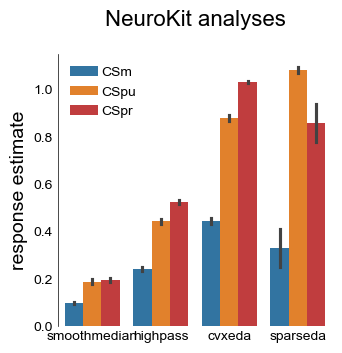

In [31]:
from lazyfmri import plotting

ev_order = ["CSm", "CSpu", "CSpr"]
palette = [stim_colors[i] for i in ev_order]

pl = plotting.LazyBar(
    comparison,
    x='method',
    y='EDA_Peak_Amplitude',
    hue='event_type',
    hue_order=ev_order,
    order=methods,
    figsize=(3.54, 3.54),
    fontname="Arial",
    add_labels=True,
    y_label='response estimate',
    bar_legend=True,
    palette=palette,
    # bbox_to_anchor=(1.2, 1.2)
    title="NeuroKit analyses"
)

In [18]:
methods

['smoothmedian', 'highpass', 'cvxeda', 'sparseda']

Text(0.5, 0.98, 'NeuroKit2 analyses')

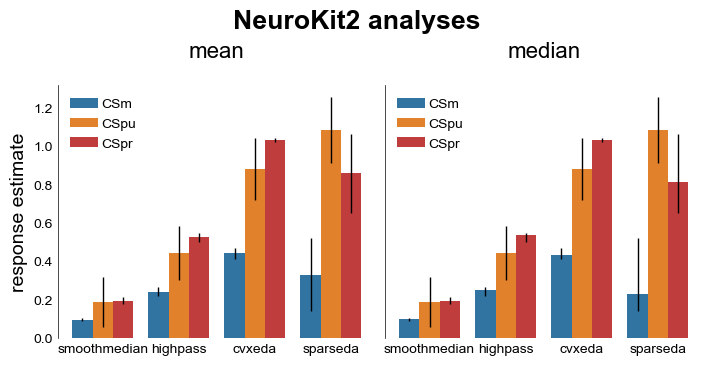

In [35]:
import matplotlib.pyplot as plt

aggr_type = ["mean", "median"]
fig, axs = plt.subplots(
    ncols=len(aggr_type),
    sharey=True,
    sharex=True,
    figsize=(7.01, 3.54),
    constrained_layout=True
)

for ix, aggr in enumerate(aggr_type):
    pl = plotting.LazyBar(
        summary,
        x="method",
        y=f"{aggr}_peak_amp",
        hue="event_type",
        order=methods,
        palette=palette,
        hue_order=ev_order,
        axs=axs[ix],
        fontname="Arial",
        add_labels=True,
        y_label="response estimate",
        bar_legend=True,
        title=aggr,
        ci_mode="columns",
        ci_low="ci_low",
        ci_high="ci_high"
    )

fig.suptitle(
    "NeuroKit2 analyses",
    fontsize=pl.title_size*1.2,
    fontweight="bold",
    fontname=pl.fontname
)